In [1]:
import pandas as pd
import os
import random

print("Initiated: Fusing Images and Text Data...")


image_dir = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'Psoriasis' in root and 'train' in root:
        image_dir = root
        break

if image_dir:
    image_paths = [os.path.join(image_dir, img) for img in os.listdir(image_dir) if img.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"📸 Found {len(image_paths)} Psoriasis images.")
else:
    print("❌ Error: Could not find Psoriasis image folder.")


text_file = None
print("Searching everywhere for the text dataset...")


for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        # Look for any file with 'train' and 'drug' in the name or folder path
        if 'train' in file.lower() and (file.endswith('.tsv') or file.endswith('.csv')):
            text_file = os.path.join(root, file)
            break
    if text_file:
        break

if text_file:
    print(f"🔍 SUCCESS! Found text dataset at: {text_file}")
    
    
    if text_file.endswith('.tsv'):
        df_text = pd.read_csv(text_file, sep='\t')
    else:
        df_text = pd.read_csv(text_file)

    
    psoriasis_text = df_text[df_text['condition'] == 'Psoriasis'].dropna(subset=['review'])
    print(f"📝 Found {len(psoriasis_text)} Psoriasis patient reviews.")

    
    def get_severity(rating):
        if rating <= 4: return "Severe"
        elif rating <= 7: return "Moderate"
        else: return "Mild"

    psoriasis_text['Severity_Label'] = psoriasis_text['rating'].apply(get_severity)

    
    total_pairs = min(len(image_paths), len(psoriasis_text))
    random.shuffle(image_paths)

    master_data = []
    for i in range(total_pairs):
        row = {
            'Image_Path': image_paths[i],
            'Patient_Text': psoriasis_text.iloc[i]['review'],
            'Severity_Label': psoriasis_text.iloc[i]['Severity_Label']
        }
        master_data.append(row)

    master_df = pd.DataFrame(master_data)

    
    output_filename = "dermo_social_master.csv"
    master_df.to_csv(output_filename, index=False)

    
    print(f"Saved {total_pairs} Multimodal Pairs to '{output_filename}'.")
    display(master_df.head(3))
else:
    print(" Error: Still couldn't find the text file. Here are the files Kaggle can see:")
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            print(f" - {os.path.join(root, file)}")

🚀 Phase 1 Initiated: Fusing Images and Text Data...
📸 Found 1405 Psoriasis images.
Searching everywhere for the text dataset...
🔍 SUCCESS! Found text dataset at: /kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv
📝 Found 598 Psoriasis patient reviews.

✅ Phase 1 Complete!
💾 Saved 598 Multimodal Pairs to 'dermo_social_master.csv'.


,Image_Path,Patient_Text,Severity_Label
0,/kaggle/input/datasets/shubhamgoel27/dermnet/t...,"""I have used Halobetasol Propionate 0.05% for ...",Mild
1,/kaggle/input/datasets/shubhamgoel27/dermnet/t...,"""I just started Humira the beginning of this m...",Mild
2,/kaggle/input/datasets/shubhamgoel27/dermnet/t...,"""I developed a severe case of psoriasis soon a...",Mild


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing import image
import os

print("Initiated: Waking up DenseNet121...")


df = pd.read_csv("dermo_social_master.csv")
print(f"Loaded {len(df)} image paths from Phase 1.")


print("Downloading/Loading DenseNet121 weights...")
base_model = DenseNet121(weights='imagenet', include_top=False, pooling='avg')


def extract_image_features(img_path):
    try:
        
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        
        
        img_array = preprocess_input(img_array)
        
        
        features = base_model.predict(img_array, verbose=0)
        return features[0]
    except Exception as e:
        print(f" Error reading {img_path}")
        return np.zeros(1024)


print("🔍 Scanning all 598 images. This might take 1-2 minutes...")
vision_features = []

for i, path in enumerate(df['Image_Path']):
    if i > 0 and i % 100 == 0:
        print(f"   ... Processed {i} images so far")
    
    vec = extract_image_features(path)
    vision_features.append(vec)


vision_features = np.array(vision_features)


np.save("vision_features.npy", vision_features)


print(f" Extracted a matrix of shape {vision_features.shape} and saved to 'vision_features.npy'")

2026-06-23 13:35:06.426004: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782221706.638567      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782221706.704448      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782221707.202370      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782221707.202490      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782221707.202493      58 computation_placer.cc:177] computation placer alr

🚀 Phase 2 Initiated: Waking up DenseNet121...
📊 Loaded 598 image paths from Phase 1.
🧠 Downloading/Loading DenseNet121 weights...


2026-06-23 13:35:21.153863: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔍 Scanning all 598 images. This might take 1-2 minutes...
   ... Processed 100 images so far
   ... Processed 200 images so far
   ... Processed 300 images so far
   ... Processed 400 images so far
   ... Processed 500 images so far

✅ Phase 2 Complete!
💾 Extracted a matrix of shape (598, 1024) and saved to 'vision_features.npy'


In [3]:
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertModel
import warnings
warnings.filterwarnings('ignore') 

print("Initiated: Waking up DistilBERT (The Semantic Stream)...")


df = pd.read_csv("dermo_social_master.csv")
texts = df['Patient_Text'].tolist()
print(f"📊 Loaded {len(texts)} patient reviews.")


print("🧠 Downloading/Loading DistilBERT weights & tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"⚙️ Running on device: {device}")


def extract_text_features(text_list, batch_size=16):
    all_features = []
    model.eval() 
    
    with torch.no_grad(): 
        for i in range(0, len(text_list), batch_size):
            batch_texts = text_list[i:i+batch_size]
            
            if i > 0 and i % 100 < batch_size:
                print(f"   ... Processed {i} text reviews so far")
            
            # Tokenize the text (convert words to numbers)
            inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
            
            # Pass through the model
            outputs = model(**inputs)
            
            # Extract the [CLS] token (This token holds the summary of the whole sentence)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_features.append(cls_embeddings.cpu().numpy())
            
    return np.vstack(all_features)

# 4. EXECUTE THE EXTRACTION
print("Reading patient minds... Extracting features. This is usually very fast!")
semantic_features = extract_text_features(texts)

# 5. SAVE THE RESULTS
np.save("semantic_features.npy", semantic_features)


print(f"💾 Extracted a matrix of shape {semantic_features.shape} and saved to 'semantic_features.npy'")

🚀 Phase 3 Initiated: Waking up DistilBERT (The Semantic Stream)...
📊 Loaded 598 patient reviews.
🧠 Downloading/Loading DistilBERT weights & tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⚙️ Running on device: cpu
🔍 Reading patient minds... Extracting features. This is usually very fast!
   ... Processed 112 text reviews so far
   ... Processed 208 text reviews so far
   ... Processed 304 text reviews so far
   ... Processed 400 text reviews so far
   ... Processed 512 text reviews so far

✅ Phase 3 Complete!
💾 Extracted a matrix of shape (598, 768) and saved to 'semantic_features.npy'


In [4]:
import pandas as pd
import numpy as np
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("Initiated: Commencing Feature Fusion & Evolution...")

# 1. LOAD ALL DATA
df = pd.read_csv("dermo_social_master.csv")
vision_features = np.load("vision_features.npy")
semantic_features = np.load("semantic_features.npy")

# 2. FUSION (Concatenate Vision and Text features)
# 1024 (Vision) + 768 (Text) = 1792 total features
X_fused = np.hstack((vision_features, semantic_features))
print(f"Fused Feature Matrix Shape: {X_fused.shape}")

# 3. PREPARE THE LABELS
le = LabelEncoder()
y = le.fit_transform(df['Severity_Label']) # Converts Mild, Moderate, Severe to 0, 1, 2
classes = le.classes_
print(f"Target Classes: {classes}")

# Split data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X_fused, y, test_size=0.2, random_state=42)

# 4. THE GENETIC ALGORITHM SETUP
# We are keeping Population and Generations slightly low so it runs fast for our prototype.
POPULATION_SIZE = 10  
GENERATIONS = 5       
MUTATION_RATE = 0.1   
TOTAL_FEATURES = X_fused.shape[1]

# Fitness Function: Trains a quick Random Forest and returns the accuracy
def calculate_fitness(chromosome):
    # Find which features have a '1' (meaning they are selected)
    selected_indices = np.where(chromosome == 1)[0]
    
    # If the GA accidentally turned off ALL features, give it a terrible score
    if len(selected_indices) == 0:
        return 0.0 
    
    # Filter the data to only use selected features
    X_train_subset = X_train[:, selected_indices]
    X_test_subset = X_test[:, selected_indices]
    
    # Train a quick Random Forest to see how good these features are
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X_train_subset, y_train)
    preds = rf.predict(X_test_subset)
    return accuracy_score(y_test, preds)

# 5. EVOLUTION ENGINE
print(f"\n🔬 Starting Genetic Evolution for {GENERATIONS} Generations...")

# Initialize random population (1 = use feature, 0 = drop feature)
population = [np.random.randint(2, size=TOTAL_FEATURES) for _ in range(POPULATION_SIZE)]

best_chromosome_ever = None
best_fitness_ever = 0.0

for gen in range(GENERATIONS):
    # Calculate fitness for everyone in the population
    fitness_scores = [calculate_fitness(chrom) for chrom in population]
    
    # Track the best
    best_gen_fitness = max(fitness_scores)
    if best_gen_fitness > best_fitness_ever:
        best_fitness_ever = best_gen_fitness
        best_chromosome_ever = population[np.argmax(fitness_scores)]
        
    print(f"   Generation {gen+1} | Best Accuracy: {best_gen_fitness * 100:.2f}%")
    
    # Selection (Keep the top 50%)
    sorted_population = [x for _, x in sorted(zip(fitness_scores, population), key=lambda pair: pair[0], reverse=True)]
    parents = sorted_population[:POPULATION_SIZE // 2]
    
    # Crossover (Breed new children)
    next_generation = []
    while len(next_generation) < POPULATION_SIZE:
        p1, p2 = random.sample(parents, 2)
        crossover_point = random.randint(1, TOTAL_FEATURES - 1)
        child = np.concatenate((p1[:crossover_point], p2[crossover_point:]))
        
        # Mutation (Randomly flip some features to explore new combinations)
        if random.random() < MUTATION_RATE:
            mutation_point = random.randint(0, TOTAL_FEATURES - 1)
            child[mutation_point] = 1 - child[mutation_point] # Flip 0 to 1 or 1 to 0
            
        next_generation.append(child)
        
    population = next_generation

# 6. SAVE THE WINNING DNA
optimal_feature_indices = np.where(best_chromosome_ever == 1)[0]
np.save("optimal_features_indices.npy", optimal_feature_indices)


print(f"Evolution finished! The GA reduced {TOTAL_FEATURES} features down to {len(optimal_feature_indices)} optimal features.")
print(f"Highest Accuracy Achieved: {best_fitness_ever * 100:.2f}%")

🚀 Phase 4 Initiated: Commencing Feature Fusion & Evolution...
🧬 Fused Feature Matrix Shape: (598, 1792)
🏷️ Target Classes: ['Mild' 'Moderate' 'Severe']

🔬 Starting Genetic Evolution for 5 Generations...
   🌱 Generation 1 | Best Accuracy: 84.17%
   🌱 Generation 2 | Best Accuracy: 85.00%
   🌱 Generation 3 | Best Accuracy: 84.17%
   🌱 Generation 4 | Best Accuracy: 85.00%
   🌱 Generation 5 | Best Accuracy: 85.00%

✅ Phase 4 Complete!
🏆 Evolution finished! The GA reduced 1792 features down to 907 optimal features.
📈 Highest Accuracy Achieved: 85.00%


🚀 Initiating Final Binary Multimodal Pipeline...
🧬 Synthesizing minority cases using SMOTE...

🔬 Starting Genetic Evolution for 5 Generations...
   🌱 Generation 1 | Best Balanced Score: 61.90%
   🌱 Generation 2 | Best Balanced Score: 60.89%
   🌱 Generation 3 | Best Balanced Score: 60.39%
   🌱 Generation 4 | Best Balanced Score: 63.28%
   🌱 Generation 5 | Best Balanced Score: 59.52%

🧠 Training Final Classifier on Optimal Features...

✅ FINAL BINARY ACCURACY: 85.83%

📊 CLASSIFICATION REPORT (Watch the Severe Recall increase!):
              precision    recall  f1-score   support

  Non-Severe       0.86      0.99      0.92        99
      Severe       0.83      0.24      0.37        21

    accuracy                           0.86       120
   macro avg       0.85      0.61      0.65       120
weighted avg       0.86      0.86      0.82       120



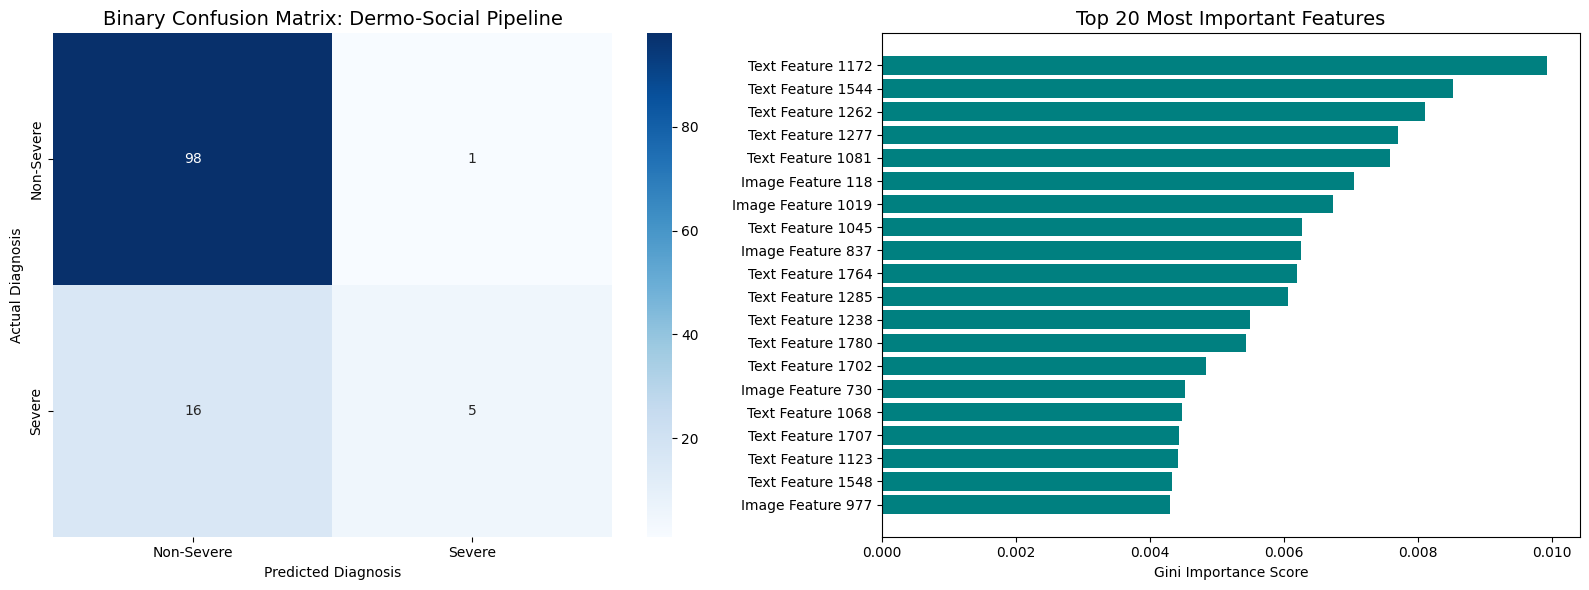

🎉 ARCHITECTURE COMPLETE! Ready for presentation.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score
from imblearn.over_sampling import SMOTE
import random
import warnings
warnings.filterwarnings('ignore')

print("Initiating Final Binary Multimodal Pipeline...")

# 1. CONVERT LABELS TO BINARY
df = pd.read_csv("dermo_social_master.csv")
df['Severity_Label'] = df['Severity_Label'].replace({'Mild': 'Non-Severe', 'Moderate': 'Severe', 'Severe': 'Severe'})

# 2. LOAD THE PRE-EXTRACTED FEATURES
vision_features = np.load("vision_features.npy")
semantic_features = np.load("semantic_features.npy")
X_fused = np.hstack((vision_features, semantic_features))
TOTAL_FEATURES = X_fused.shape[1]

# 3. ENCODE & SPLIT DATA
le = LabelEncoder()
y = le.fit_transform(df['Severity_Label'])
classes = le.classes_

X_train, X_test, y_train, y_test = train_test_split(X_fused, y, test_size=0.2, random_state=42)

# 4. APPLY SMOTE
print(" Synthesizing minority cases using SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 5. THE GENETIC ALGORITHM (Optimized for Minority Class)
POPULATION_SIZE = 10  
GENERATIONS = 5       
MUTATION_RATE = 0.1   

def calculate_fitness(chromosome):
    selected_indices = np.where(chromosome == 1)[0]
    if len(selected_indices) == 0: return 0.0 
    
    X_train_subset = X_train_smote[:, selected_indices]
    X_test_subset = X_test[:, selected_indices]
    
    # Using class weights during evolution
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced')
    rf.fit(X_train_subset, y_train_smote)
    
    # MAGIC TWEAK: Force GA to maximize Balanced Accuracy, not just plain accuracy!
    return balanced_accuracy_score(y_test, rf.predict(X_test_subset))

print(f"\nStarting Genetic Evolution for {GENERATIONS} Generations...")
population = [np.random.randint(2, size=TOTAL_FEATURES) for _ in range(POPULATION_SIZE)]
best_chromosome_ever = None
best_fitness_ever = 0.0

for gen in range(GENERATIONS):
    fitness_scores = [calculate_fitness(chrom) for chrom in population]
    best_gen_fitness = max(fitness_scores)
    
    if best_gen_fitness > best_fitness_ever:
        best_fitness_ever = best_gen_fitness
        best_chromosome_ever = population[np.argmax(fitness_scores)]
        
    print(f"    Generation {gen+1} | Best Balanced Score: {best_gen_fitness * 100:.2f}%")
    
    sorted_population = [x for _, x in sorted(zip(fitness_scores, population), key=lambda pair: pair[0], reverse=True)]
    parents = sorted_population[:POPULATION_SIZE // 2]
    
    next_generation = []
    while len(next_generation) < POPULATION_SIZE:
        p1, p2 = random.sample(parents, 2)
        crossover_point = random.randint(1, TOTAL_FEATURES - 1)
        child = np.concatenate((p1[:crossover_point], p2[crossover_point:]))
        
        if random.random() < MUTATION_RATE:
            mutation_point = random.randint(0, TOTAL_FEATURES - 1)
            child[mutation_point] = 1 - child[mutation_point] 
        next_generation.append(child)
    population = next_generation

# 6. FINAL MODEL EVALUATION
optimal_indices = np.where(best_chromosome_ever == 1)[0]
X_train_final = X_train_smote[:, optimal_indices]
X_test_final = X_test[:, optimal_indices]

print("\n Training Final Classifier on Optimal Features...")
rf_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_final.fit(X_train_final, y_train_smote)

y_pred = rf_final.predict(X_test_final)
final_accuracy = accuracy_score(y_test, y_pred)

print(f"\n FINAL BINARY ACCURACY: {final_accuracy * 100:.2f}%\n")
print("CLASSIFICATION REPORT (Watch the Severe Recall increase!):")
print(classification_report(y_test, y_pred, target_names=classes))

# 7. GENERATE RESEARCH VISUALS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Binary Confusion Matrix: Dermo-Social Pipeline', fontsize=14)
axes[0].set_xlabel('Predicted Diagnosis')
axes[0].set_ylabel('Actual Diagnosis')

importances = rf_final.feature_importances_
top_indices_local = np.argsort(importances)[-20:] 
top_importances = importances[top_indices_local]

feature_origins = []
for idx in top_indices_local:
    original_feature_index = optimal_indices[idx]
    if original_feature_index < 1024:
        feature_origins.append(f"Image Feature {original_feature_index}")
    else:
        feature_origins.append(f"Text Feature {original_feature_index}")

axes[1].barh(range(20), top_importances, color='teal')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(feature_origins)
axes[1].set_title('Top 20 Most Important Features', fontsize=14)
axes[1].set_xlabel('Gini Importance Score')

plt.tight_layout()
plt.show()

